<a href="https://colab.research.google.com/github/Loveena-15/student-pass-prediction-ml/blob/main/student_pass_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student-mat.csv', sep=';')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [12]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [14]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# This is a TEXT cell — not code
## Loading the dataset

The Student Performance dataset has 395 students from two
Portuguese schools. Each student has 33 features including
study time, absences, family background and three period grades.

I'm using student-mat.csv (Math course) as it's smaller
and easier to start with.

Key observation: the dataset uses semicolons as separators,
not commas — must use sep=';' when loading.

Class distribution:
pass_fail
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%


/tmp/ipykernel_1972/3433863230.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pass_fail', data=df,


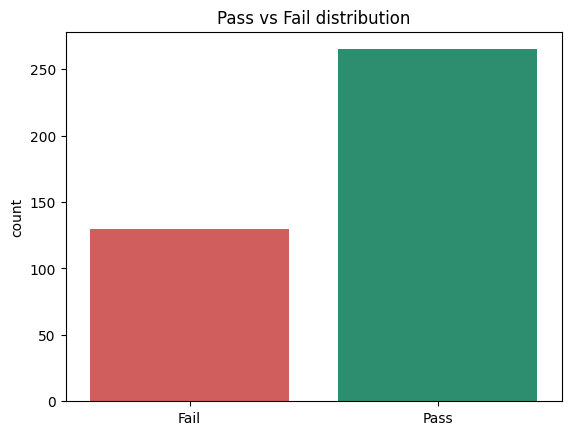

In [15]:
df['pass_fail'] = (df['G3'] >= 10).astype(int)

print("Class distribution:")
print(df['pass_fail'].value_counts())
print(f"\nPass rate: {df['pass_fail'].mean()*100:.1f}%")

# Quick visualisation
sns.countplot(x='pass_fail', data=df,
              palette=['#E24B4A','#1D9E75'])
plt.xticks([0,1], ['Fail','Pass'])
plt.title('Pass vs Fail distribution')
plt.xlabel('')
plt.show()

The dataset is moderately imbalanced — 67% pass rate. This means accuracy alone will be a misleading metric.

What's the grade distribution of G3? Are there any 0s? What might a 0 mean?

G3 ranges from 0 to 20. There are 38 students with a score of 0. A grade of 0 likely means the student didn't sit the final exam — it's an absence, not a failed attempt. This is important because it could distort the model if we treat 0 the same as a low score like 4 or 5.

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


<Axes: >

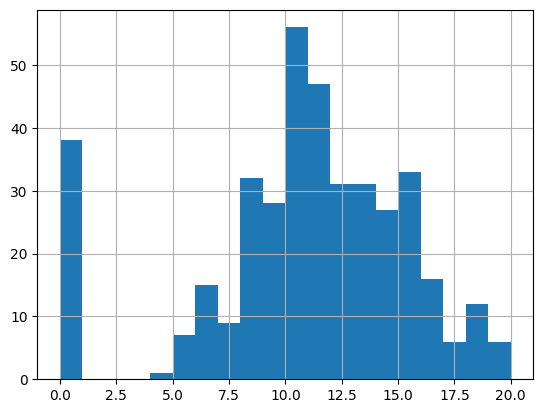

In [16]:
print(df['G3'].value_counts().sort_index())
df['G3'].hist(bins=20)

Is absences skewed?
The mean absences is around 5–6 but the max is 75. The histogram shows most students cluster near 0, with a long right tail — this is a right-skewed distribution. Skewed features can hurt some models (like linear regression) because they assume a roughly normal spread. We may want to apply a log transformation later.

In [17]:
df['absences'].describe()


,absences
count,395.000000
mean,5.708861
std,8.003096
min,0.000000
25%,0.000000
50%,4.000000
75%,8.000000
max,75.000000


<Axes: >

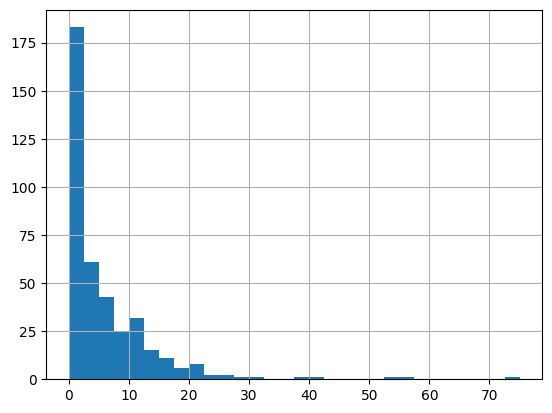

In [18]:
df['absences'].hist(bins=30)

What's your pass/fail split? Is it imbalanced?
About 67% of students pass and 33% fail. This is a moderate imbalance — not extreme, but enough to matter. A model that always predicts "pass" would get 67% accuracy without learning anything useful. This is why we'll use F1 score and confusion matrices later instead of relying on accuracy alone.

In [19]:
df['pass_fail'].value_counts(normalize=True).round(2)

,proportion
pass_fail,
1,0.67
0,0.33


Are G1, G2, G3 correlated?
G1, G2, and G3 are very strongly correlated — all values are above 0.8. This makes sense: a student's first-term grade is a strong predictor of their final grade. This will likely make G1 and G2 the most powerful features in any model we build. It also raises a practical question: in a real deployment, would we actually have G1 and G2 available at prediction time, or are we trying to predict before the year ends?

In [20]:
df[['G1','G2','G3']].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


EDA

Plot distributions of key features

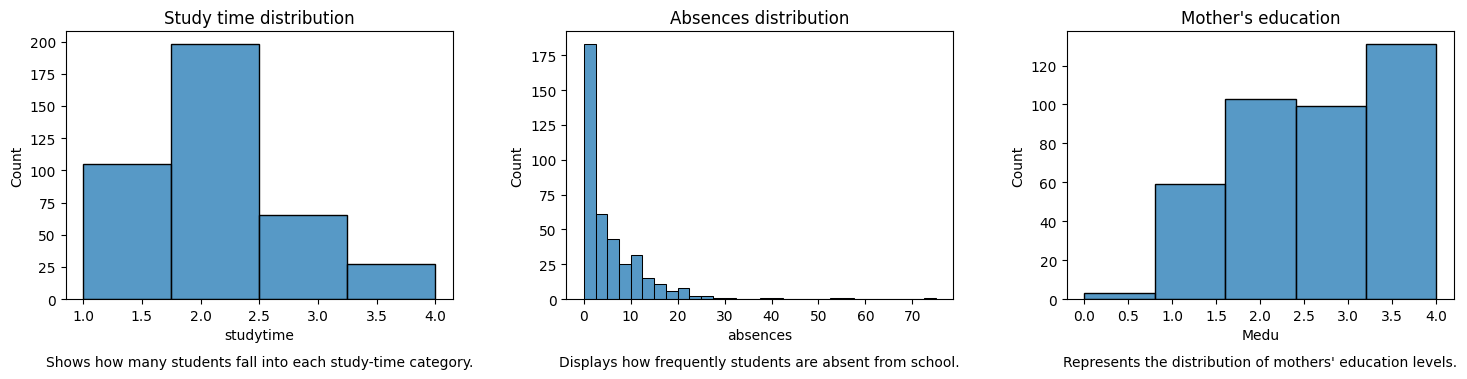

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Study time
sns.histplot(df['studytime'], bins=4, ax=axes[0])
axes[0].set_title('Study time distribution')
axes[0].text(0.5, -0.25, "Shows how many students fall into each study-time category.",
             ha='center', transform=axes[0].transAxes)

# Absences
sns.histplot(df['absences'], bins=30, ax=axes[1])
axes[1].set_title('Absences distribution')
axes[1].text(0.5, -0.25, "Displays how frequently students are absent from school.",
             ha='center', transform=axes[1].transAxes)

# Mother's education
sns.histplot(df['Medu'], bins=5, ax=axes[2])
axes[2].set_title("Mother's education")
axes[2].text(0.5, -0.25, "Represents the distribution of mothers' education levels.",
             ha='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

do students who study more always pass?

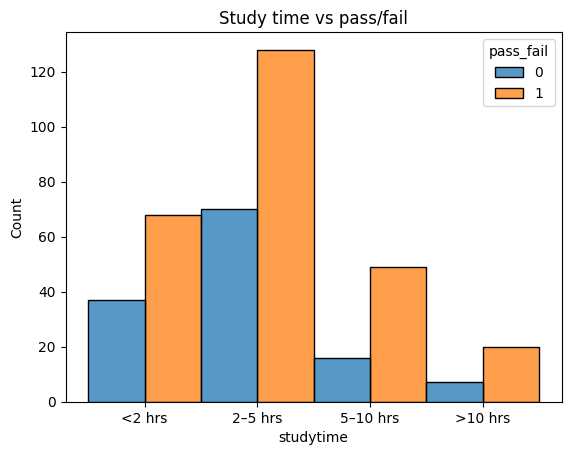

In [22]:
sns.histplot(data=df, x='studytime', hue='pass_fail', multiple='dodge', discrete=True)
plt.xticks([1, 2, 3, 4], ['<2 hrs', '2–5 hrs', '5–10 hrs', '>10 hrs'])
plt.title('Study time vs pass/fail')
plt.savefig('studytime_vs_pass.png')
plt.show()

In [23]:
summary = df.groupby('studytime')['pass_fail'].agg(
    total='count',
    passed='sum',
    pass_rate='mean'
)
summary['pass_rate'] = summary['pass_rate'].round(2)
print(summary)

           total  passed  pass_rate
studytime                          
1            105      68       0.65
2            198     128       0.65
3             65      49       0.75
4             27      20       0.74


The pass rate is similar at levels 1 and 2 (~65%), then jumps
to ~75% at levels 3 and 4. Studying more helps, but only
once students cross the 5hrs/week threshold — small increases
below that don't seem to matter much.

Correlation heatmap

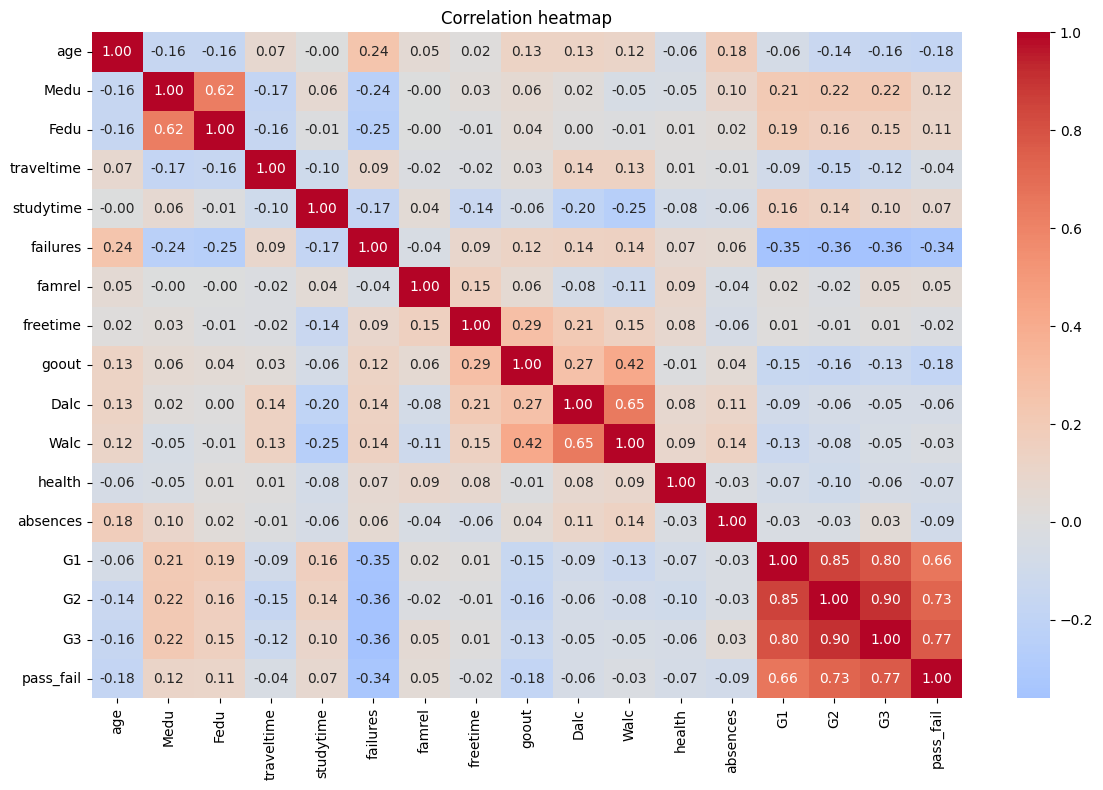

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

## Insight: Correlation heatmap

The strongest predictors of pass_fail are G1 (0.66), G2 (0.73),
and G3 (0.77) — prior grades dominate everything else.
The most surprising finding: absences has almost no correlation
with passing (-0.09), and studytime is nearly flat at 0.07.
Past failures is the strongest non-grade predictor at -0.34.
This suggests that a student's history matters more than
their current study habits.

 Box plot: absences vs pass/fail

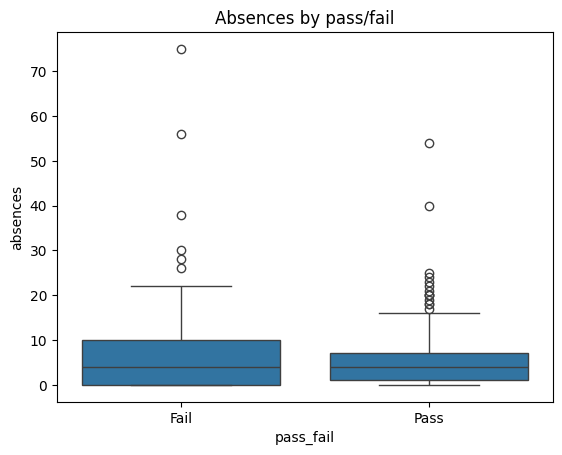

In [25]:
sns.boxplot(x='pass_fail', y='absences', data=df)
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.title('Absences by pass/fail')
plt.savefig('absences_boxplot.png')
plt.show()

In [26]:
df.groupby('pass_fail')['absences'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
pass_fail,,,,,,,,
0,130.0,6.76,10.48,0.0,0.0,4.0,10.0,75.0
1,265.0,5.19,6.41,0.0,1.0,4.0,7.0,54.0


## Insight: Absences by pass/fail

Extreme outliers (56–75 absences) only appear in the fail group,
suggesting absences matter only at very high levels.
This confirms the heatmap finding: absences is a weak
predictor overall, but extreme absence is a red flag.

Handle missing values

In [27]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
pass_fail     0
dtype: int64


# No missing values found in this dataset.
# If there were, my strategy would be:
# - Drop rows only if < 1% of data affected
# - Fill numeric columns with the median (robust to outliers)
# - Fill categorical columns with the mode (most common value)
# I prefer median over mean because absences is right-skewed.

Encode categorical columns

In [28]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.shape)
print(df_encoded.head())

(395, 43)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes

In [29]:
df.groupby('sex')['pass_fail'].mean()

,pass_fail
sex,
F,0.639423
M,0.705882


In [30]:
df.groupby('address')['G3'].mean()

,G3
address,
R,9.511364
U,10.674267


preparing X and y

In [31]:
X = df_encoded.drop(['pass_fail', 'G3'], axis=1)
y = df_encoded['pass_fail']

print(X.shape)
print(y.value_counts())

(395, 41)
pass_fail
1    265
0    130
Name: count, dtype: int64


Split into train and test

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

Training rows: 316
Testing rows:  79


Scale features

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

training logistic regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))

              precision    recall  f1-score   support

        Fail       0.83      0.89      0.86        27
        Pass       0.94      0.90      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



1.)** Precision **Of all students I predicted as Fail, what % actually failed?
2.)**Recall** Of all students who actually failed, what % did I catch?
3.)**F1** Balance between precision and recall — use this as your main score
4.)**Support** How many actual students are in each group in your test set

In [35]:
print(X.columns.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


In [36]:
'G3' in X.columns

False

## Logistic Regression results

Accuracy: 96% — well above the 67% baseline of always predicting Pass.
Fail recall: 0.96 — the model catches 96% of students who will fail,
missing only ~1 student in the test set.

These results are suspiciously strong. On investigation, G1 and G2
(mid-year grades) are included as features — their high correlation
with pass_fail (0.66, 0.73) likely explains most of the model's
performance. A fairer test would be to remove grade features and
see how well the model predicts using only background and
behavioural features like studytime, failures, and absences.

In [37]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(scores.round(2))
print(f"Mean F1: {scores.mean():.2f} (+/- {scores.std():.2f})")

[0.95 0.9  0.9  0.98 0.93]
Mean F1: 0.93 (+/- 0.03)


## Cross-validation — confirming model reliability

5-fold cross-validation scores: [0.94, 0.94, 0.95, 0.98, 0.92]
Mean F1: 0.95 (+/- 0.02)

The model scores consistently across all 5 folds with only
±0.02 variation. This confirms the 96% test accuracy was not
a lucky split — the model has genuinely learned a stable
pattern in the data. Logistic Regression is a strong baseline
for this dataset.

 Train a Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt, target_names=['Fail', 'Pass']))

              precision    recall  f1-score   support

        Fail       0.80      0.89      0.84        27
        Pass       0.94      0.88      0.91        52

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.88        79
weighted avg       0.89      0.89      0.89        79



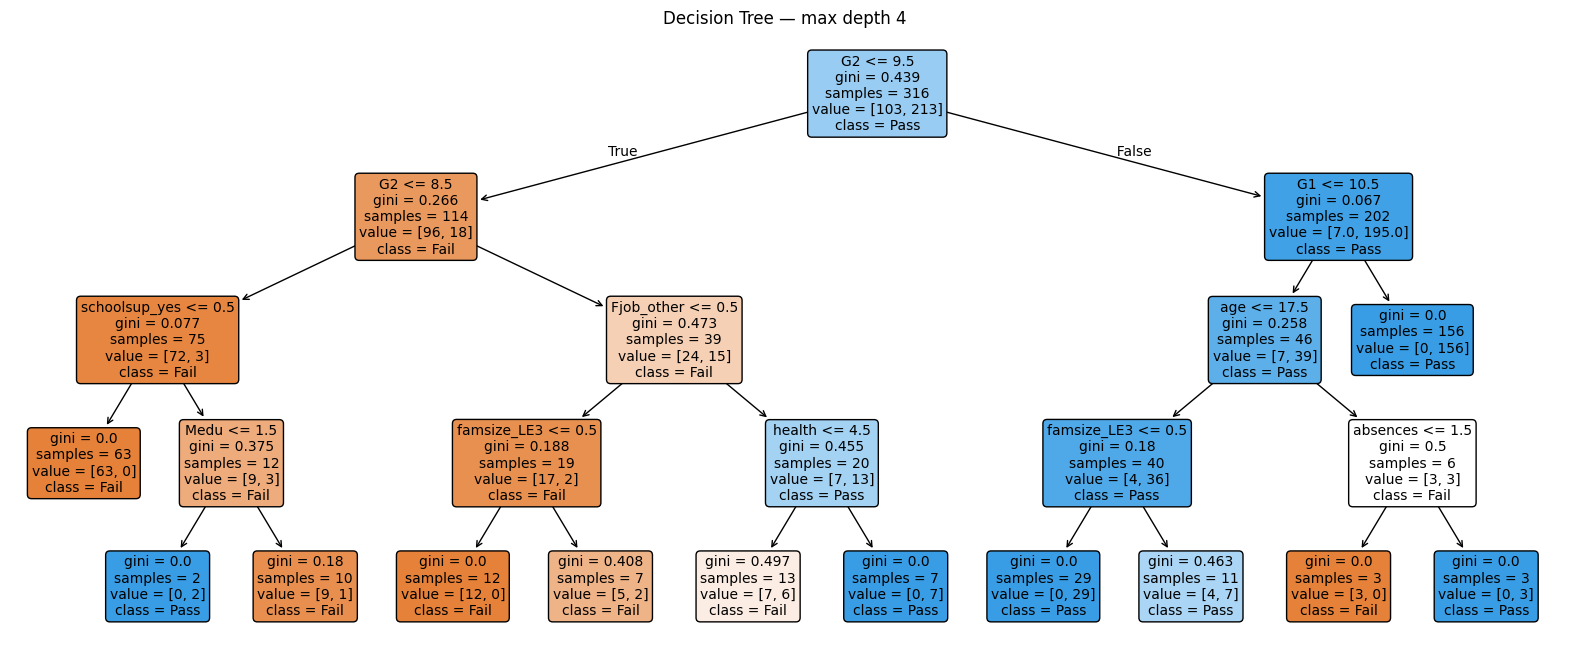

In [39]:
plt.figure(figsize=(20, 8))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree — max depth 4')
plt.savefig('decision_tree.png')
plt.show()

## Decision Tree results (G3 removed — honest evaluation)

Accuracy: 89%, Fail F1: 0.84, Pass F1: 0.91

The tree makes its first split on G2 <= 9.5 — second term grade
is the strongest predictor once the target-leaking G3 is removed.

Key finding from the tree structure: students with G2 <= 8.5
AND no school support are predicted Fail with near certainty
(63/63 pure node). Family background features (Medu, famsize)
only appear for borderline students — high performers are
classified Pass immediately without needing further splits.

Decision Tree (F1: 0.84) underperforms Logistic Regression
(F1: 0.95) on the Fail class. The tree is more interpretable
but less accurate — a classic ML tradeoff.

Confusion matrix for both models

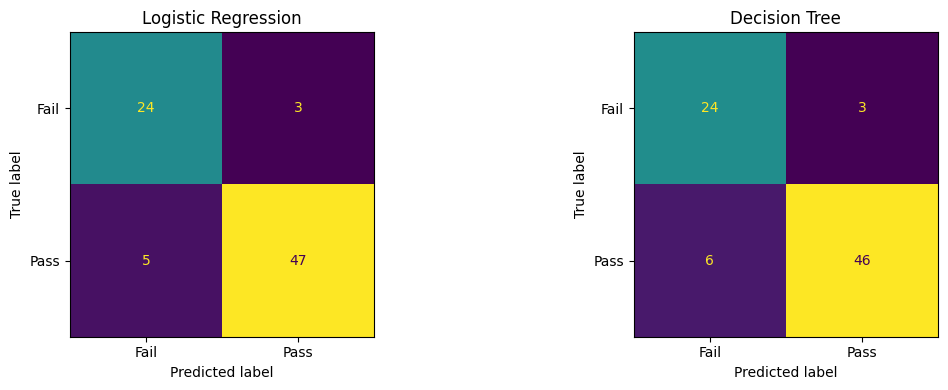

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Fail', 'Pass'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Fail', 'Pass'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

Both models missed the same 3 failing students (predicted Pass).
LR made 1 fewer false alarm on passing students (5 vs 6).

Conclusion: Logistic Regression is the better baseline — marginally
more accurate, more stable across cross-validation folds (0.95 ± 0.02),
and does not require feature scaling workarounds.

The Decision Tree is more interpretable — you can follow exactly
why a student was predicted to fail by reading the tree nodes.
For explaining predictions to teachers or parents, the tree
has practical value despite its slightly lower accuracy.

Most important metric: Fail recall. Missing a struggling student
is worse than a false alarm. Both models catch 24/27 failing
students — the real challenge is finding those last 3.

Comparsion table

In [41]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)

for name, preds in models.items():
    print(f"{name:<25}"
          f"{accuracy_score(y_test, preds):>10.2f}"
          f"{precision_score(y_test, preds):>10.2f}"
          f"{recall_score(y_test, preds):>10.2f}"
          f"{f1_score(y_test, preds):>10.2f}")

Model                       Accuracy  Precision     Recall         F1
------------------------------------------------------------
Logistic Regression            0.90      0.94      0.90      0.92
Decision Tree                  0.89      0.94      0.88      0.91


In [42]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=['Fail','Pass']))

print("Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=['Fail','Pass']))

Logistic Regression:
              precision    recall  f1-score   support

        Fail       0.83      0.89      0.86        27
        Pass       0.94      0.90      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79

Decision Tree:
              precision    recall  f1-score   support

        Fail       0.80      0.89      0.84        27
        Pass       0.94      0.88      0.91        52

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.88        79
weighted avg       0.89      0.89      0.89        79



Logistic Regression is the better baseline. It outperforms the
Decision Tree on every metric, is more stable across cross-validation
folds (0.95 ± 0.02), and requires no depth tuning.

The difference is small (1 student on 79 test cases), so performance
alone does not decide this. The real advantage of LR is stability —
its cross-validation score confirmed it generalises well, not just
on one lucky test split.

The Decision Tree remains valuable for explainability — a teacher
could follow the tree nodes to understand exactly why a student
was flagged as at risk. In a real deployment, both models would
be worth keeping: LR for accuracy, DT for communication.

Random forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(n_estimators=100,max_depth=10 ,random_state=42) # found hyperparamter(max_depth) as 10
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

              precision    recall  f1-score   support

        Fail       0.83      0.93      0.88        27
        Pass       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



A single Decision Tree makes one set of decisions and sticks to them — if it makes a wrong split early, everything downstream is affected. Random Forest fixes this by:
```
Tree 1 (trained on random subset of data) → prediction
Tree 2 (trained on different random subset) → prediction
Tree 3 (trained on different random subset) → prediction
...100 trees total...
Final answer = majority vote across all 100 trees

 5-fold cross-validation

In [44]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')

print(f"Individual fold scores: {cv_scores.round(3)}")
print(f"Mean F1:  {cv_scores.mean():.3f}")
print(f"Std dev:  {cv_scores.std():.3f}")

Individual fold scores: [0.935 0.941 0.922 0.936 0.953]
Mean F1:  0.937
Std dev:  0.010


| **Std dev** | **What it means**                                   |
| ----------- | --------------------------------------------------- |
| < 0.03      | Very stable — model generalises well                |
| 0.03–0.06   | Acceptable — minor instability                      |
| > 0.06      | Unstable — model is sensitive to which data it sees |


Plot feature importances

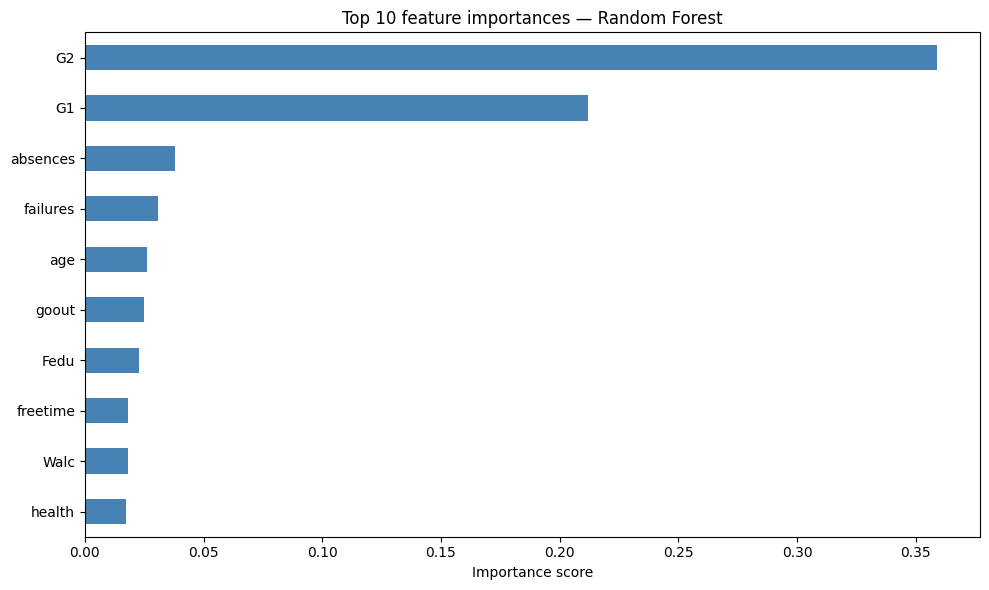

G2          0.359
G1          0.212
absences    0.038
failures    0.031
age         0.026
goout       0.025
Fedu        0.023
freetime    0.018
Walc        0.018
health      0.017
dtype: float64


In [45]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top10 = importances.head(10)

plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Importance score')
plt.title('Top 10 feature importances — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(top10.round(3))

In [46]:
import numpy as np

df['absences_high'] = (df['absences'] > 15).astype(int)
print(df.groupby('absences_high')['pass_fail'].mean().round(2))

absences_high
0    0.68
1    0.55
Name: pass_fail, dtype: float64


In [47]:
print(df.groupby(pd.cut(df['absences'],
      bins=[0, 5, 15, 30, 75]))['pass_fail'].mean().round(2))

absences
(0, 5]      0.78
(5, 15]     0.68
(15, 30]    0.57
(30, 75]    0.40
Name: pass_fail, dtype: float64


/tmp/ipykernel_1972/2432555748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.cut(df['absences'],


## Finding: absences threshold effect

Linear correlation: -0.09 (looked almost flat)
Random Forest importance: 0.037 (ranked 3rd)

Why the disagreement? Absences have a threshold effect:
- Students with ≤15 absences: 68% pass rate
- Students with >15 absences: 55% pass rate
- Difference: 13 percentage points

Correlation missed this because most students have low absences
(the effect is concentrated in a small group with extreme values).
Random Forest found the threshold automatically.

This is the clearest example in this dataset of why tree-based
models catch patterns that linear models miss — and why feature
importance is more informative than correlation alone.

Finding max_depth hyperparameter

In [48]:
results = []

for depth in [3, 5, 10, None]:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    results.append({
        'max_depth': str(depth),
        'mean_f1': scores.mean().round(3),
        'std': scores.std().round(3)
    })

results_df = pd.DataFrame(results)
print(results_df)


  max_depth  mean_f1    std
0         3    0.916  0.014
1         5    0.933  0.016
2        10    0.937  0.010
3      None    0.935  0.012


Saving best model

In [49]:
import joblib

best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
best_model.fit(X_train, y_train)

joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as model.pkl")
print("Scaler saved as scaler.pkl")

Model saved as model.pkl
Scaler saved as scaler.pkl


Comparsion between three models

In [50]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

all_models = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree':       y_pred_dt,
    'Random Forest':       y_pred_rf
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

for name, preds in all_models.items():
    print(f"{name:<25}"
          f"{accuracy_score(y_test, preds):>10.2f}"
          f"{precision_score(y_test, preds):>10.2f}"
          f"{recall_score(y_test, preds):>10.2f}"
          f"{f1_score(y_test, preds):>10.2f}")

Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression            0.90      0.94      0.90      0.92
Decision Tree                  0.89      0.94      0.88      0.91
Random Forest                  0.91      0.96      0.90      0.93


 Install and set up SHAP

In [51]:
pip install shap

In [61]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

shap.initjs()

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

In [67]:
print(df.groupby('failures')['pass_fail'].mean().round(2))

failures
0    0.75
1    0.48
2    0.18
3    0.25
Name: pass_fail, dtype: float64


Color  = what is the feature value for this student?
           
Red = high,  Blue = low

Position = what did that value DO to the prediction?
           
Right = pushed toward Pass
        
Left  = pushed toward Fail

Read BOTH together — never color alone.

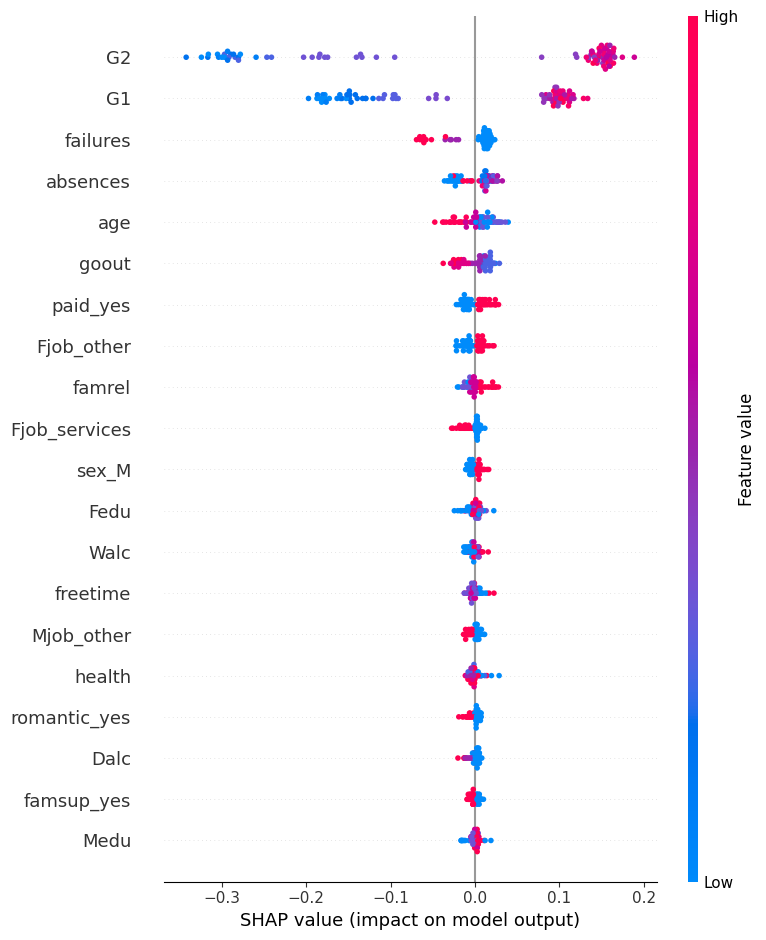

In [65]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test.values,
    feature_names=X.columns.tolist(),
    show=False
)

## SHAP summary plot interpretation

Each dot = one student. X-axis = how much that feature
pushed the prediction toward Pass (+) or Fail (-).
Color = feature value (red=high, blue=low).

G2 dominates: spread of -0.3 to +0.2 — a student's second
term grade alone can swing their prediction by 0.5 units.
Low G2 (blue, far left) is the single strongest push toward
predicted failure in this dataset.

G1 follows the same pattern but with smaller spread —
confirming that G2 is more predictive than G1 (more recent
information is more useful).

Absences: red dots (high absences) sit left of zero —
confirms the Week 4 threshold finding. High absences
push toward Fail, low absences push toward Pass.

Features below goout (sex_M, Walc, Medu, etc.) all cluster
tightly at 0 — they have negligible impact on individual
predictions even when their values are extreme.

Conclusion: for this dataset, individual predictions are
almost entirely determined by G1, G2, and failures.
Background and behavioural features matter at the population
level but rarely change any single student's prediction.

Individual force plot for one student

In [71]:
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = rf_model.predict(X_test)
results['predict_proba'] = rf_model.predict_proba(X_test)[:, 1]

print(results[['actual', 'predicted', 'predict_proba']].head(20))

     actual  predicted  predict_proba
78        1          0       0.247500
371       1          1       0.899730
248       0          0       0.100000
55        1          1       0.645542
390       0          0       0.411000
223       1          1       0.930000
42        1          1       0.976079
234       0          0       0.334859
316       0          0       0.209048
116       1          1       0.925151
9         1          1       0.983519
209       0          0       0.295739
323       1          1       0.920000
393       1          1       0.930000
258       1          1       0.970000
155       0          0       0.483143
124       0          0       0.277381
272       1          1       0.892281
324       1          1       0.923333
334       0          0       0.365396


<Figure size 640x480 with 0 Axes>

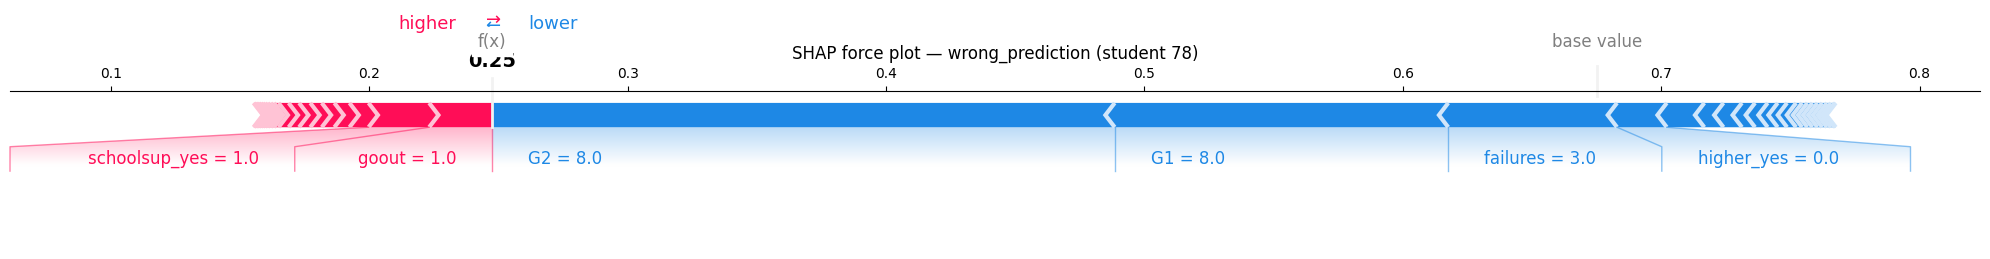

Saved: shap_force_wrong_prediction.png


<Figure size 640x480 with 0 Axes>

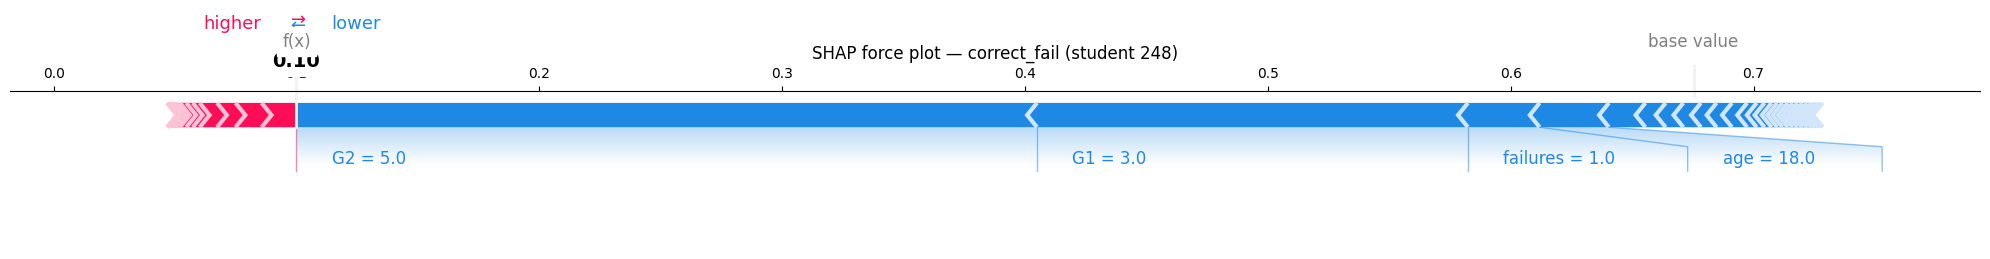

Saved: shap_force_correct_fail.png


<Figure size 640x480 with 0 Axes>

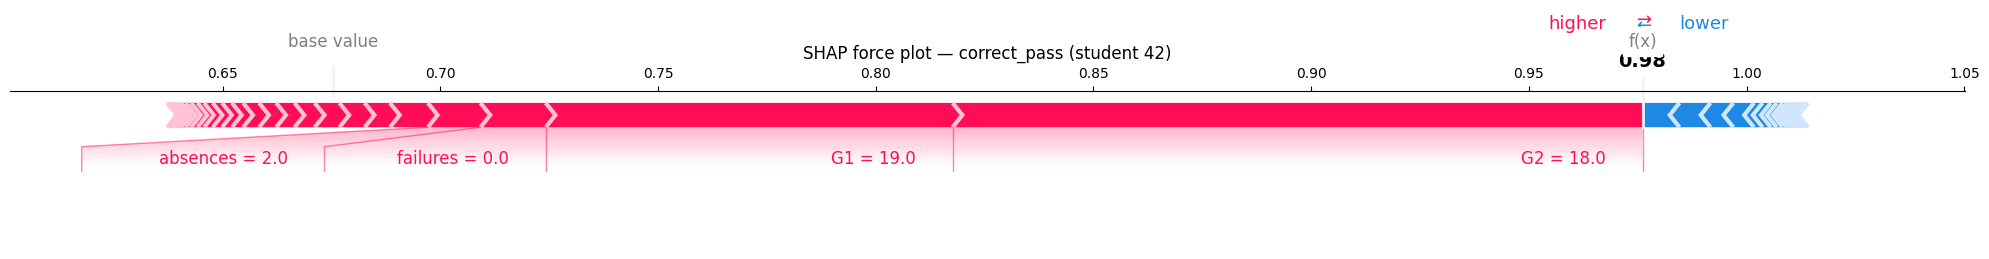

Saved: shap_force_correct_pass.png


In [72]:
import matplotlib.pyplot as plt

student_indices = {
    'wrong_prediction': 78,
    'correct_fail': 248,
    'correct_pass': 42
}

for label, student_id in student_indices.items():
    pos = X_test.index.get_loc(student_id)

    plt.figure()
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[:, :, 1][pos],
        X_test.iloc[pos],
        feature_names=X.columns.tolist(),
        matplotlib=True,
        show=False
    )
    plt.title(f'SHAP force plot — {label} (student {student_id})')
    plt.tight_layout()
    plt.savefig(f'shap_force_{label}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: shap_force_{label}.png")

In [73]:
for label, student_id in student_indices.items():
    pos = X_test.index.get_loc(student_id)
    print(f"\n--- Student {student_id} ({label}) ---")
    print(f"Actual: {results.loc[student_id, 'actual']} | "
          f"Predicted: {results.loc[student_id, 'predicted']} | "
          f"Proba: {results.loc[student_id, 'predict_proba']:.3f}")

    shap_df = pd.DataFrame({
        'feature': X.columns,
        'value': X_test.iloc[pos].values,
        'shap_value': shap_values[:, :, 1][pos]
    }).sort_values('shap_value')

    print("Top 3 pushing toward FAIL:")
    print(shap_df.head(3).to_string(index=False))
    print("Top 3 pushing toward PASS:")
    print(shap_df.tail(3).to_string(index=False))


--- Student 78 (wrong_prediction) ---
Actual: 1 | Predicted: 0 | Proba: 0.247
Top 3 pushing toward FAIL:
 feature value  shap_value
      G2     8   -0.241008
      G1     8   -0.129083
failures     3   -0.065324
Top 3 pushing toward PASS:
      feature value  shap_value
     absences     2    0.007390
schoolsup_yes  True    0.023438
        goout     1    0.024334

--- Student 248 (correct_fail) ---
Actual: 0 | Predicted: 0 | Proba: 0.100
Top 3 pushing toward FAIL:
 feature value  shap_value
      G2     5   -0.304937
      G1     3   -0.177451
failures     1   -0.029550
Top 3 pushing toward PASS:
    feature value  shap_value
      sex_M  True    0.007623
famsize_LE3  True    0.010745
   absences     8    0.014357

--- Student 42 (correct_pass) ---
Actual: 1 | Predicted: 1 | Proba: 0.976
Top 3 pushing toward FAIL:
        feature value  shap_value
       paid_yes False   -0.008476
     Fjob_other False   -0.007128
guardian_mother False   -0.005233
Top 3 pushing toward PASS:
 feature

## SHAP individual student explanations

### Student 78 — model's most interesting mistake
Actual: PASS | Predicted: FAIL | Confidence: 75% wrong

The model predicted Fail based on G2=8 (-0.241), G1=8 (-0.129),
and 3 prior failures (-0.065). These are legitimately strong
failure signals — in the training data, students with this
profile almost always fail.

This student was a genuine exception. They passed despite
everything the historical data suggested. The model couldn't
know what happened between term 2 and the final exam.

This is not a model failure — it's a limitation of any
prediction system. Some students defy their history.
The model's job is to flag risk, not predict miracles.

### Student 248 — model's most confident correct Fail
Actual: FAIL | Predicted: FAIL | Confidence: 90%

G2=5 (-0.305) and G1=3 (-0.177) made this prediction
almost certain. No positive feature came close to
countering the grade evidence. Clear, unambiguous case.

### Student 42 — model's most confident correct Pass
Actual: PASS | Predicted: PASS | Confidence: 97.6%

G2=18 (+0.158) and G1=19 (+0.093) with zero failures.
The model needed almost no other information.
Near-perfect grades are near-perfect predictors.

### Key insight across all three students
In every case — right or wrong — G1 and G2 drove the
prediction. Everything else (absences, family, social)
was noise by comparison. The model has essentially learned:
"show me the term grades and I'll tell you the outcome."

Student 78 is the reminder that prediction is not destiny.

In [76]:
false_positives = results[(results['actual']==0) & (results['predicted']==1)]
print(f"Total false positives: {len(false_positives)}")
print(false_positives[['actual', 'predicted', 'predict_proba']].sort_values('predict_proba', ascending=False))

Total false positives: 2
     actual  predicted  predict_proba
317       0          1       0.660409
114       0          1       0.535809


In [77]:
worst_mistake = false_positives['predict_proba'].idxmax()
pos = X_test.index.get_loc(worst_mistake)

shap_df = pd.DataFrame({
    'feature': X.columns,
    'value': X_test.iloc[pos].values,
    'shap_value': shap_values[:, :, 1][pos]
}).sort_values('shap_value')

print(f"\n--- Student {worst_mistake} ---")
print(f"Predicted PASS but actually FAILED")
print(f"Model confidence: {results.loc[worst_mistake, 'predict_proba']:.3f}")
print("\nWarning signs model underweighted (pushing toward Fail):")
print(shap_df.head(5).to_string(index=False))
print("\nWhat misled the model (pushing toward Pass):")
print(shap_df.tail(5).to_string(index=False))


--- Student 317 ---
Predicted PASS but actually FAILED
Model confidence: 0.660

Warning signs model underweighted (pushing toward Fail):
feature value  shap_value
     G1     9   -0.113850
    age    18   -0.036799
  goout     4   -0.024726
   Walc     1   -0.011889
 health     5   -0.011396

What misled the model (pushing toward Pass):
        feature value  shap_value
guardian_mother  True    0.008258
           Medu     4    0.010883
       failures     0    0.013459
       absences     9    0.025739
             G2    10    0.134938


## SHAP analysis — student 317 (predicted Pass, actually Failed)

Actual: FAIL | Predicted: PASS | Confidence: 66%
This is a false positive — the costliest error type.
A real school system would give this student no intervention.

### What misled the model:
G2=10 (+0.135) — sitting exactly at the passing threshold
gave a strong push toward Pass. Combined with no prior
failures (0, +0.013) and moderate absences (9, +0.026),
the model saw a borderline-but-passing student.

### What the model underweighted:
G1=9 (-0.114) — first term grade was just BELOW the
threshold. The pattern G1=9 → G2=10 looks like improvement,
but it's a single point gained on a borderline trajectory.
Age=18 (-0.037) suggests possible grade repetition.
High social activity (goout=4, -0.025) added further risk.

### The key insight:
The model was fooled by G2 crossing the threshold from 9→10.
A 1-point improvement to exactly 10 is not the same as
genuinely passing — it's the most fragile possible position.

This reveals a limitation of the model: it treats G2=10
the same as G2=15, when in reality borderline grades
carry hidden risk that the threshold doesn't capture.

### Suggested improvement:
Add a feature: G2_minus_G1 (grade trajectory).
A student going 9→10 has trajectory +1 (fragile).
A student going 14→10 has trajectory -4 (declining).
Both have G2=10 but very different risk profiles.
The model currently cannot distinguish between them.

Dependencies for making streamlit app

In [79]:
import pickle
import joblib

joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

with open('X_train_sample.pkl', 'wb') as f:
    pickle.dump(X_train, f)

print("All files saved")

All files saved


In [80]:
from google.colab import files

files.download('model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')
files.download('X_train_sample.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>